# 4. Mushroom foraging

The [mushroom dataset](https://www.kaggle.com/datasets/dhinaharp/mushroom-dataset) contains data about approximately 60000 mushrooms, and your task is to classify them as either edible or poisonous. You can read about the features [here](https://www.kaggle.com/datasets/uciml/mushroom-classification) and import the data using:

In [1]:
import pandas as pd
pd.set_option('display.max_columns', 1000)
df = pd.read_csv('secondary_data.csv', delimiter = ';')
df.head()

,class,cap-diameter,cap-shape,cap-surface,cap-color,does-bruise-or-bleed,gill-attachment,gill-spacing,gill-color,stem-height,stem-width,stem-root,stem-surface,stem-color,veil-type,veil-color,has-ring,ring-type,spore-print-color,habitat,season
0,p,15.26,x,g,o,f,e,NaN,w,16.95,17.09,s,y,w,u,w,t,g,NaN,d,w
1,p,16.60,x,g,o,f,e,NaN,w,17.99,18.19,s,y,w,u,w,t,g,NaN,d,u
2,p,14.07,x,g,o,f,e,NaN,w,17.80,17.74,s,y,w,u,w,t,g,NaN,d,w
3,p,14.17,f,h,e,f,e,NaN,w,15.77,15.98,s,y,w,u,w,t,p,NaN,d,w
4,p,14.64,x,h,o,f,e,NaN,w,16.53,17.20,s,y,w,u,w,t,p,NaN,d,w


It's up to you how you approach this data, but at a minimum, your analysis should include:

* Informed **data preparation**.
* 2 different classification models, one of which must be **logistic regression**.
* A discussion of which **performance metric** is most relevant for the evaluation of your models.
* 2 different **validation methodologies** used to tune hyperparameters.
* **Confusion matrices** for your models, and associated comments.

**DATA PREPARATION**


In [2]:
print(df.shape)
print(df.dtypes)

print(df.isnull().sum())

from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()
for col in df_encoded.columns:
    df_encoded[col] = LabelEncoder().fit_transform(df_encoded[col])


(61069, 21)
class                    object
cap-diameter            float64
cap-shape                object
cap-surface              object
cap-color                object
does-bruise-or-bleed     object
gill-attachment          object
gill-spacing             object
gill-color               object
stem-height             float64
stem-width              float64
stem-root                object
stem-surface             object
stem-color               object
veil-type                object
veil-color               object
has-ring                 object
ring-type                object
spore-print-color        object
habitat                  object
season                   object
dtype: object
class                       0
cap-diameter                0
cap-shape                   0
cap-surface             14120
cap-color                   0
does-bruise-or-bleed        0
gill-attachment          9884
gill-spacing            25063
gill-color                  0
stem-height                 0
st

**SPLIT DATA**

In [3]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop('class', axis=1)
y = df_encoded['class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


**TRAIN MODELS**

In [4]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Without scaling, the model stuggled to converge, so I applied Scaler to normalize all input featrues.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Define models
lr_model = LogisticRegression(max_iter=5000, class_weight='balanced', random_state=42)
rf_model = RandomForestClassifier(random_state=42)


**VALIDATION**

In [ ]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

# Logistic Regression validation
param_grid_lr = {'C': [0.1, 1]}
grid_lr = GridSearchCV(lr_model, param_grid_lr, cv=3)
grid_lr.fit(X_train_scaled, y_train)

# Random Forest validation
param_dist_rf = {'n_estimators': [50, 100], 'max_depth': [10]}
random_rf = RandomizedSearchCV(rf_model, param_distributions=param_dist_rf, n_iter=2, cv=3, random_state=42)
random_rf.fit(X_train, y_train)


RandomizedSearchCV(cv=3, estimator=RandomForestClassifier(random_state=42),
                   n_iter=2,
                   param_distributions={'max_depth': [10],
                                        'n_estimators': [50, 100]},
                   random_state=42)

I used n_estimators to test how many trees impact performance using reasonable defaults. 
* max_depth = [10] limits tree growth and helps prevent overfitting.
* RandomizedSearchCV with just 2 iterations ensures the tuning process is fast and practical for a large dataset.
* used cv = 3 for cross-validation to reduce runtime while maintaining a reliable estimate of model performance.

In [11]:
print("Best Logistic Regression params:", grid_lr.best_params_)
print("Best Random Forest params:", random_rf.best_params_)

Best Logistic Regression params: {'C': 1}
Best Random Forest params: {'n_estimators': 100, 'max_depth': 10}


**Performance Metric**

In [12]:

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def print_metrics(model, X_test, y_test, name):
    y_pred = model.predict(X_test)
    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred, zero_division=0))
    print("Recall:", recall_score(y_test, y_pred, zero_division=0))
    print("F1 Score:", f1_score(y_test, y_pred, zero_division=0))
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f"{name} Confusion Matrix")
    plt.show()



Logistic Regression (Tuned, Scaled)
Accuracy: 0.6420501064352383
Precision: 0.7031610141587092
Recall: 0.6244152046783625
F1 Score: 0.6614526870063497


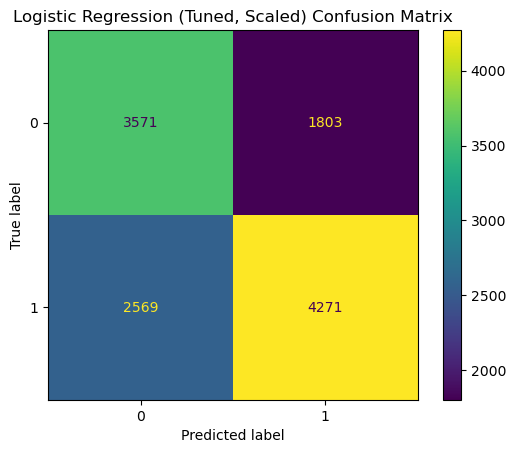


Random Forest (Tuned)
Accuracy: 0.9923039135418372
Precision: 0.9989644970414201
Recall: 0.987280701754386
F1 Score: 0.9930882352941176


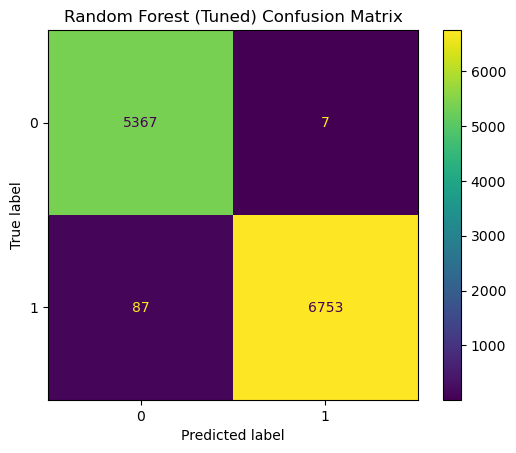

In [13]:

print_metrics(grid_lr, X_test_scaled, y_test, "Logistic Regression (Tuned, Scaled)")
print_metrics(random_rf, X_test, y_test, "Random Forest (Tuned)")


Confusion matrix:
* Logistic Regression - The model catches about 62% of all poisonous mushrroms, which is not great.
* Randomn Forets - The model almost never misclassifies poisonous mushrooms.



The most important metric is Recall for the poisonous class.
A false negative is far more dangerous than a false positive, high recall ensures we catch as many posinous mushrooms as possible.